In [11]:
import os
from llama_index.core import Settings
from llama_index.llms.groq import Groq

In [12]:
Settings.llm = Groq(model="llama-3.3-70b-versatile",
                    api_key=os.environ.get("GROQ_API_KEY"))

In [13]:
from llama_index.experimental.query_engine import PandasQueryEngine

In [14]:
import pandas as pd

df = pd.read_csv("vendas.csv")

In [15]:
query_engine = PandasQueryEngine(df=df, verbose=True)

In [16]:
response = query_engine.query("Qual é o tipo de produto mais vendido?")

> Pandas Instructions:
```
df['tipo_produto'].value_counts().idxmax()
```
> Pandas Output: Moda


In [17]:
df.tipo_produto.value_counts().index[0]

'Moda'

In [18]:
response = query_engine.query("Qual é a cidade que usou mais Dinheiro como forma de pagamento?")

> Pandas Instructions:
```
df.loc[df['forma_pagamento'] == 'Dinheiro', 'cidade'].value_counts().idxmax()
```
> Pandas Output: São Caetano


In [20]:
df.loc[df['forma_pagamento'] == 'Dinheiro', 'cidade'].value_counts().index[0]

'São Caetano'

In [19]:
response

Response(response='São Caetano', source_nodes=[], metadata={'pandas_instruction_str': "df.loc[df['forma_pagamento'] == 'Dinheiro', 'cidade'].value_counts().idxmax()", 'raw_pandas_output': 'São Caetano'})

### Respostas mais elaboradas

In [21]:
query_engine = PandasQueryEngine(df=df, 
                                 verbose=True,
                                 synthesize_response=True)

In [22]:
response = query_engine.query("Qual é a avaliação média de cada filial?")
response

> Pandas Instructions:
```
df.groupby('filial')['avaliacao'].mean()
```
> Pandas Output: filial
A    7.027059
B    6.818072
C    7.072866
Name: avaliacao, dtype: float64


Response(response='A avaliação média de cada filial é a seguinte: \n- Filial A: 7.03\n- Filial B: 6.82\n- Filial C: 7.07\n\nEsses valores indicam que a filial C tem a avaliação média mais alta, seguida pela filial A e, por fim, pela filial B.', source_nodes=[], metadata={'pandas_instruction_str': "df.groupby('filial')['avaliacao'].mean()", 'raw_pandas_output': 'filial\nA    7.027059\nB    6.818072\nC    7.072866\nName: avaliacao, dtype: float64'})

In [23]:
str(response)

'A avaliação média de cada filial é a seguinte: \n- Filial A: 7.03\n- Filial B: 6.82\n- Filial C: 7.07\n\nEsses valores indicam que a filial C tem a avaliação média mais alta, seguida pela filial A e, por fim, pela filial B.'

In [24]:
import textwrap

def format_text(response):
    text = response.response
    text_formatted = textwrap.fill(text, width=100)
    print(text_formatted)

In [25]:
format_text(response)

A avaliação média de cada filial é a seguinte:  - Filial A: 7.03 - Filial B: 6.82 - Filial C: 7.07
Esses valores indicam que a filial C tem a avaliação média mais alta, seguida pela filial A e, por
fim, pela filial B.


### Geração de Gráficos

In [26]:
response = query_engine.query("Exiba pra mim a distribuição das avaliações")

> Pandas Instructions:
```
df['avaliacao'].value_counts()
```
> Pandas Output: avaliacao
6.0     26
6.6     24
        ..
4.6      8
10.0     5
Name: count, Length: 61, dtype: int64


In [27]:
format_text(response)

A distribuição das avaliações é bastante variada, com 61 níveis diferentes de avaliação. As
avaliações mais comuns são 6,0 e 6,6, que aparecem 26 e 24 vezes, respectivamente. Já as avaliações
menos comuns são 4,6 e 10,0, que aparecem apenas 8 e 5 vezes, respectivamente.   Aqui está uma visão
geral da distribuição:  - Avaliação 6,0: 26 ocorrências - Avaliação 6,6: 24 ocorrências - Avaliação
4,6: 8 ocorrências - Avaliação 10,0: 5 ocorrências  E existem 57 outras avaliações com frequências
variadas. Se você precisar de mais detalhes, posso fornecer a lista completa.


> Pandas Instructions:
```
df['avaliacao'].plot.hist(bins=10, figsize=(10, 6), title='Distribuição das Avaliações')
```
> Pandas Output: Axes(0.125,0.11;0.775x0.77)


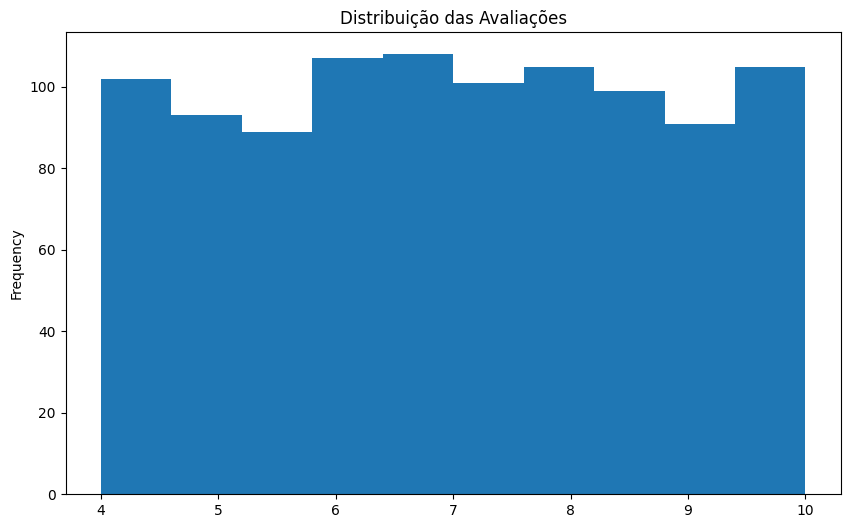

In [28]:
response = query_engine.query("Exiba pra mim um gráfico da distribuição das avaliações")

> Pandas Instructions:
```
df.groupby('tipo_produto')['total'].sum().sort_values(ascending=True).plot(kind='barh')
```
> Pandas Output: Axes(0.125,0.11;0.775x0.77)


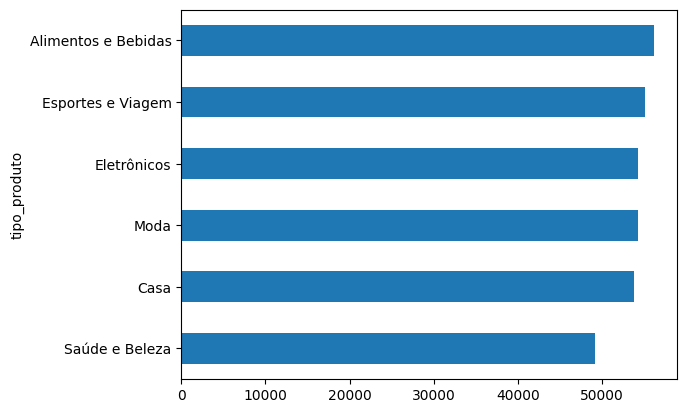

In [29]:
response = query_engine.query("""
    Crie um gráfico da soma do total por tipo_produto ordenando
    do menor para maior e mantenha a barra na horizontal
                              """)